End-to-End Insight Projekt: Játékosérték és Promóció Analízis

1. Könyvtárak importálása

In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


2. Adatok betöltése

Az adatok szintetikusak, random generáltak

In [21]:
xls = pd.ExcelFile('Szerencsejatek_Zrt_Minta_Projekt.xlsx')
df_p = pd.read_excel(xls, 'Dim_Jatekosok')
df_t = pd.read_excel(xls, 'Fact_Tranzakciok')
df_pr = pd.read_excel(xls, 'Fact_Promociok')

In [22]:
print(df_p.head())

   Jatekos_ID Korcsoport Regisztracio_Tipusa Szegmens
0        1001        50+             Lottozo      VIP
1        1002        50+              Online  Alkalmi
2        1003      18-25              Online      VIP
3        1004      18-25             Lottozo      VIP
4        1005      36-50             Lottozo      VIP


In [24]:
print(df_t.head())

   Tranzakcio_ID  Jatekos_ID      Datum Jatek_Tipusa  Osszeg
0           5001        1099 2026-01-05      Tippmix    7555
1           5002        1063 2026-01-08     Sorsjegy   13860
2           5003        1025 2026-03-12     Sorsjegy   13992
3           5004        1029 2026-04-19         Keno   14582
4           5005        1018 2026-01-20     Sorsjegy   11166


In [25]:
print(df_pr.head())

   Jatekos_ID Promocios_kod_felhasznalva Nyeremeny_visszaforgatva
0        1001                        Nem                     Igen
1        1002                        Nem                      Nem
2        1003                        Nem                      Nem
3        1004                        Nem                     Igen
4        1005                        Nem                      Nem


3. Táblák egyesítése

In [26]:
df = df_t.merge(df_p, on='Jatekos_ID').merge(df_pr, on='Jatekos_ID')

In [27]:
df

,Tranzakcio_ID,Jatekos_ID,Datum,Jatek_Tipusa,Osszeg,Korcsoport,Regisztracio_Tipusa,Szegmens,Promocios_kod_felhasznalva,Nyeremeny_visszaforgatva
0,5001,1099,2026-01-05,Tippmix,7555,50+,Lottozo,Alkalmi,Igen,Igen
1,5002,1063,2026-01-08,Sorsjegy,13860,50+,Online,Rendszeres,Nem,Igen
2,5003,1025,2026-03-12,Sorsjegy,13992,50+,Lottozo,VIP,Nem,Igen
3,5004,1029,2026-04-19,Keno,14582,36-50,Online,Alkalmi,Igen,Igen
4,5005,1018,2026-01-20,Sorsjegy,11166,50+,Online,Rendszeres,Igen,Nem
...,...,...,...,...,...,...,...,...,...,...
295,5296,1004,2026-04-18,Lotto,6790,18-25,Lottozo,VIP,Nem,Igen
296,5297,1019,2026-04-27,Keno,9700,50+,Lottozo,VIP,Igen,Nem
297,5298,1078,2026-02-08,Lotto,8781,18-25,Lottozo,Rendszeres,Igen,Igen
298,5299,1087,2026-04-12,Keno,11199,36-50,Lottozo,VIP,Nem,Nem


4. Leíró statisztika

In [28]:
print("--- Csoportosított statisztika (Promóció hatása) ---")
print(df.groupby('Promocios_kod_felhasznalva')['Osszeg'].describe())
print("-" * 50)

--- Csoportosított statisztika (Promóció hatása) ---
                            count        mean          std    min      25%  \
Promocios_kod_felhasznalva                                                   
Igen                        160.0  8060.41875  4031.083813  657.0  4758.25   
Nem                         140.0  7901.90000  3764.591566  572.0  4696.00   

                               50%       75%      max  
Promocios_kod_felhasznalva                             
Igen                        8324.5  11595.25  14786.0  
Nem                         7978.0  10959.00  14968.0  
--------------------------------------------------


3. EDA - Vizualizáció

C:\Users\erika\AppData\Local\Temp\ipykernel_19176\403876440.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Promocios_kod_felhasznalva', y='Osszeg', data=df, palette='viridis')


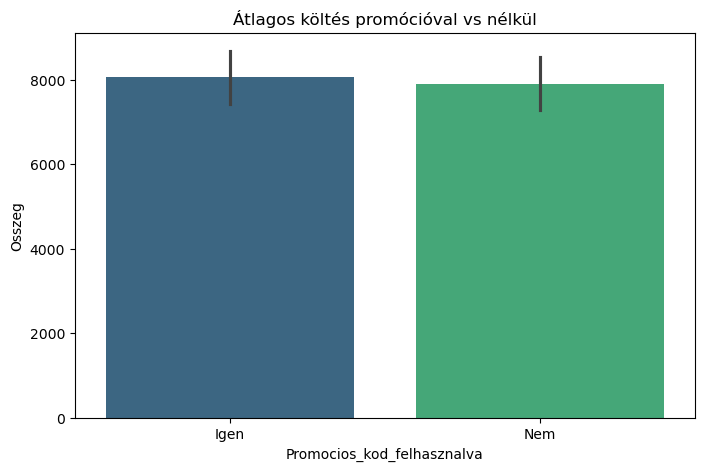

In [30]:

plt.figure(figsize=(8,5))
sns.barplot(x='Promocios_kod_felhasznalva', y='Osszeg', data=df, palette='viridis')
plt.title('Átlagos költés promócióval vs nélkül')
plt.show()

4. Predikció VIP

In [6]:
# 4. Predikció (VIP jóslás)
df['Is_VIP'] = (df['Szegmens'] == 'VIP').astype(int)
df_ml = pd.get_dummies(df[['Osszeg', 'Korcsoport', 'Jatek_Tipusa']], drop_first=True)
X = df_ml
y = df['Is_VIP']

# Modell betanítása
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("--- Predikciós Modell Jelentés ---")
print(classification_report(y_test, model.predict(X_test)))

--- Predikciós Modell Jelentés ---
              precision    recall  f1-score   support

           0       0.69      0.80      0.74        60
           1       0.40      0.27      0.32        30

    accuracy                           0.62        90
   macro avg       0.54      0.53      0.53        90
weighted avg       0.59      0.62      0.60        90



5. Kétmintás t-próba

In [2]:
from scipy import stats

# Csoportok szétválasztása az összeg alapján
kuponos = df[df['Promocios_kod_felhasznalva'] == 'Igen']['Osszeg']
kontroll = df[df['Promocios_kod_felhasznalva'] == 'Nem']['Osszeg']

# Kétmintás t-próba lefuttatása
t_stat, p_val = stats.ttest_ind(kuponos, kontroll)

print(f"T-statisztika: {t_stat:.4f}")
print(f"P-érték: {p_val:.4f}")

# Értékelés:
if p_val > 0.05:
    print("Insight: A különbség statisztikailag nem szignifikáns (p > 0.05).")
else:
    print("Insight: A különbség statisztikailag szignifikáns (p <= 0.05).")

T-statisztika: 0.3504
P-érték: 0.7263
Insight: A különbség statisztikailag nem szignifikáns (p > 0.05).


In [3]:
df.groupby('Promocios_kod_felhasznalva')['Osszeg'].describe()

,count,mean,std,min,25%,50%,75%,max
Promocios_kod_felhasznalva,,,,,,,,
Igen,160.0,8060.41875,4031.083813,657.0,4758.25,8324.5,11595.25,14786.0
Nem,140.0,7901.90000,3764.591566,572.0,4696.00,7978.0,10959.00,14968.0
